<a href="https://colab.research.google.com/github/D2718281828nis/BioMedAI-sEEG-core-of-epilepsy/blob/main/sEEG_multimodal_object_model_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multimodal object model: EDF + DICOM + reservoir, verified against the recording's own annotation

This notebook is the single, executable walkthrough of the object-model pipeline the installable `object_model` package implements. Unlike the other five notebooks in this repository, it does **not** reimplement any signal-processing logic itself — it installs the actual package (`extreme_event_agent`, `model`, `multimodal_approach`, `object_model`) and calls exactly the functions those packages export, in the same order `object_model.run_object_model.run` does, with a markdown cell between every step explaining what that step can and cannot claim.

**1. The setup.** Nothing is known about the object (a human brain) in advance. Two descriptions of it exist, in two different modalities: a time series (`sEEG-HFOs-8.edf`, stereo-EEG) and an image (`dataset/MRI-with-electrodes/DCM`, post-implant structural MRI). One piece of ground truth exists: the recording's own EDF+ annotation of a bilateral tonic-clonic seizure (`приступ + БТКП`, decoded from the file's `cp1251` annotation channel).

**2. What each modality can and cannot give — decided here, not discovered at the end:**

| Modality | Temporal marker | Spatial marker |
|---|---|---|
| EDF (stereo-EEG) | **yes**, sub-second resolution | **yes**, down to a single contact |
| DICOM (structural MRI) | **impossible in principle** — a static post-implant scan has no time axis | **yes, but hemisphere granularity only** |
| Reservoir plant (on EDF) | **yes** | **yes**, down to a contact — if the residual isn't collapsed |

A structural MRI is a single snapshot taken after implantation; it has no temporal axis under any amount of processing, so asking it for a time is a category error, not an unmet requirement. The honest reading this notebook follows: **temporal verification is EDF-internal** (two live methods against the annotation); **spatial verification is cross-modal** (lateralization index compared between EDF, DICOM, and the reservoir); **DICOM stays hemisphere-level** (no verified 3-D electrode localization exists in this repository — see `multimodal_approach/README.md`, "Honest limits").

## 1. Install the package and its dependencies

**If you hit `ModuleNotFoundError: No module named 'extreme_event_agent'` after running this section:** it almost always means the kernel actually running this notebook is not the same Python environment the `%pip install` cell installed into (e.g. a Jupyter server with only an Anaconda/base kernel registered, while `pip install -e .` was previously run for a different interpreter from a terminal) -- `sys.executable`, printed below, is the environment that matters. The next cell installs into *that exact* interpreter via `%pip` (not `!pip`, which can silently target a different one). After it finishes, **restart this notebook's kernel** and re-run from the top -- a fresh editable install is not always picked up by an already-running kernel without a restart. The verification cell right after the install will fail loudly, with this same guidance, if the import still does not work.

In [1]:
import os
import sys
from pathlib import Path

if not Path("pyproject.toml").exists():
    if not Path("BioMedAI-sEEG-core-of-epilepsy").exists():
        get_ipython().system("git clone --quiet https://github.com/D2718281828nis/BioMedAI-sEEG-core-of-epilepsy.git")
    os.chdir("BioMedAI-sEEG-core-of-epilepsy")

# extreme_event_agent/dicom_viewer are proper editable-installed packages (pyproject.toml
# packages.find where=['src']) and importable from anywhere once installed below. model/,
# multimodal_approach/, and object_model/ are plain top-level directories that pyproject.toml
# does not package -- see model/run_model.py's own docstring: 'run as a module ... from the
# repo root'. Adding the repo root to sys.path explicitly (rather than relying on a kernel's
# default sys.path behavior) makes every import below work regardless of how this notebook is
# actually launched.
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
print(f"Working directory: {Path.cwd()}")
print(f"Kernel interpreter (sys.executable): {sys.executable}")
print("^ %pip below installs into THIS interpreter. If that is not the environment you expect "
      "(e.g. it says .../anaconda3/... but you meant a project .venv), switch the notebook's kernel "
      "to the right interpreter before continuing.")

Working directory: /Users/denmacair/Documents/code_base/BioMedAI-sEEG-core-of-epilepsy
Kernel interpreter (sys.executable): /opt/anaconda3/bin/python
^ %pip below installs into THIS interpreter. If that is not the environment you expect (e.g. it says .../anaconda3/... but you meant a project .venv), switch the notebook's kernel to the right interpreter before continuing.


In [2]:
# No -q: install output is left visible on purpose, so a real failure here (a missing system
# dependency for mne/pydicom, a network error, ...) is seen now rather than surfacing later as a
# confusing ModuleNotFoundError with no context.
%pip install -e .

Obtaining file:///Users/denmacair/Documents/code_base/BioMedAI-sEEG-core-of-epilepsy
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for seeg-extreme-event-agent (pyproject.toml) ... done
  Created wheel for seeg-extreme-event-agent: filename=seeg_extreme_event_agent-0.1.0-0.editable-py3-none-any.whl size=2781 sha256=58ae92fd904b78f6b0abc287d6af48573c805d357ffb82fbcb490dd7941184b5
  Stored in directory: /private/var/folders/57/nnp0s5hs27d65fbf6n2frbjh0000gn/T/pip-ephem-wheel-cache-jkj2nimw/wheels/e0/55/5b/48cba61cc12216bf0d09c44a58fb8e902b6f2cf55376a94822
Successfully built seeg-extreme-event-agent
  Attempting uninstall: seeg-extreme-event-agent
    Found existing installation: seeg-extreme-event-agent 0.1.0
    Uninstalling seeg-extreme-event-agent-0.1.0:
      Successfully uninstalled seeg-extreme-event-ag

In [3]:
# Self-check: confirms the install actually landed in *this* kernel before anything below runs.
try:
    import extreme_event_agent  # noqa: F401
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "extreme_event_agent still is not importable from this kernel "
        f"({sys.executable}) after the install above.\n"
        "Most likely fix: RESTART THIS NOTEBOOK'S KERNEL now, then re-run every cell from the top "
        "(Kernel > Restart Kernel and Run All Cells, or the equivalent in your IDE) -- an editable "
        "install is not always visible to an already-running kernel.\n"
        "If that does not fix it: scroll up to the install cell's output for the real error, and "
        "confirm the notebook's selected kernel matches the interpreter printed above."
    ) from error
print(f"extreme_event_agent importable from {sys.executable}: OK")

extreme_event_agent importable from /opt/anaconda3/bin/python: OK


## 2. Locate the dataset

`dataset/` is intentionally not committed to this repository (see the top-level README). The EDF is required; the DICOM directory is optional -- if it is not found, Block B below is skipped with an explicit message rather than raising, and Block C's lateralization comparison then runs on EDF and reservoir evidence only.

> Colab runs Linux, so a Windows-style local path should be uploaded or mounted at `/content/dataset/...` instead. Use Colab's **Files** panel, or uncomment the upload snippet below.

In [4]:
# Optional browser upload (uncomment only if the files are not already present).
# from google.colab import files
# uploaded = files.upload()  # select sEEG-HFOs-8.edf
# Path("/content/dataset").mkdir(parents=True, exist_ok=True)
# for name in uploaded:
#     Path(name).replace(Path("/content/dataset") / name)

In [5]:
edf_candidates = [Path('/content/dataset/sEEG-HFOs-8.edf'), Path('dataset/sEEG-HFOs-8.edf')]
edf_path = next((p for p in edf_candidates if p.is_file()), None)
if edf_path is None:
    searched = '\n'.join(f'  - {p.resolve()}' for p in edf_candidates)
    raise FileNotFoundError(f'sEEG-HFOs-8.edf not found. Upload it with the cell above. Searched:\n{searched}')

dicom_candidates = [Path('/content/dataset/MRI-with-electrodes/DCM'), Path('dataset/MRI-with-electrodes/DCM')]
dicom_dir = next((p for p in dicom_candidates if p.is_dir()), None)
if dicom_dir is None:
    print('No DICOM directory found -- Block B will be skipped. '
          'Upload dataset/MRI-with-electrodes/DCM to include it.')
else:
    print(f'EDF: {edf_path.resolve()}')
    print(f'DICOM: {dicom_dir.resolve()}')

EDF: /Users/denmacair/Documents/code_base/BioMedAI-sEEG-core-of-epilepsy/dataset/sEEG-HFOs-8.edf
DICOM: /Users/denmacair/Documents/code_base/BioMedAI-sEEG-core-of-epilepsy/dataset/MRI-with-electrodes/DCM


## 3. Block A -- EDF: temporal and spatial markers

`analyse_brain_process` produces, from the signal alone, every recruitment latency and the single globally earliest crossing (`tau_min`) -- with **no** reference to any contact list. `likely_initiators` additionally intersects that with the clinical prior (`SEEG_HFOS_8_CLINICAL_PRIOR`, PM3-8/CC8-10); `earliest_contacts`/`hemisphere_of_earliest` are the prior-free reading of the same recording, published specifically so the prior-constrained reading can be checked against it rather than taken on trust -- see the top-level README, "How `likely_initiators` is computed".

In [6]:
from extreme_event_agent.edf_workflow import (analyse_brain_process, build_seizure_graph,
                                               find_annotated_event, read_edf)
from extreme_event_agent.agent import ExtremeEventAgent
from extreme_event_agent.edf_workflow import select_seizure_event

CROP_END_SECONDS = 10550.0  # excludes the post-seizure surgical cauterization segment -- see README

annotated = find_annotated_event(edf_path)
if annotated is None:
    raise ValueError(f'{edf_path} carries no EDF+ annotated seizure -- this notebook needs that ground truth.')
print(f'Annotation cluster: {annotated.annotations}')
print(f'Reference (БТКП) time: {annotated.time_seconds:.3f} s')

data, sfreq, names = read_edf(edf_path, crop_end_seconds=CROP_END_SECONDS)
process = analyse_brain_process(data, sfreq, names, annotated)

print(f'tau_min = {process.earliest_latency_seconds:.3f} s ({len(process.earliest_contacts)} tied channels)')
print(f'hemisphere_of_earliest = {process.hemisphere_of_earliest!r}')
print(f'prior_fraction_among_earliest = {process.prior_fraction_among_earliest:.3f}')
print(f'initiators_constrained_by_prior = {process.initiators_constrained_by_prior}')
print(f'likely_initiators (prior-constrained): {process.likely_initiators}')
print(f'earliest_contacts (prior-free, first {min(10, len(process.earliest_contacts))} of '
      f'{len(process.earliest_contacts)}): {process.earliest_contacts[:10]}')

blind_report = ExtremeEventAgent().run(data, sfreq, names)
blind_event = select_seizure_event(blind_report.events)
print(f't_blind (tier-3 blind pick): {blind_event.time_seconds:.3f} s' if blind_event else 'no blind candidate')

graph = build_seizure_graph(data, sfreq, names, annotated, process) if process.onset_latency_seconds else None
print(f'Recruitment graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges' if graph else 'no graph')

Annotation cluster: ((10392.734, 'где тут начало?'), (10396.445, 'приступ + БТКП'), (10399.469, 'клиника'))
Reference (БТКП) time: 10396.445 s
tau_min = 0.035 s (92 tied channels)
hemisphere_of_earliest = 'mixed'
prior_fraction_among_earliest = 0.098
initiators_constrained_by_prior = False
likely_initiators (prior-constrained): ('EEG PM3', 'EEG PM4', 'EEG PM5', 'EEG PM6', 'EEG PM7', 'EEG PM8', 'EEG CC8', 'EEG CC9', 'EEG CC10')
earliest_contacts (prior-free, first 10 of 92): ('EEG R1', 'EEG R2', 'EEG R3', 'EEG R4', 'EEG R5', 'EEG R6', 'EEG R7', 'EEG R8', 'EEG R9', 'EEG R10')
t_blind (tier-3 blind pick): 10438.000 s
Recruitment graph: 99 nodes, 371 edges


## 4. Block B -- DICOM: structural asymmetry (hemisphere granularity only)

`run_structural_anomaly` computes a self-referential hemispheric asymmetry map -- no population reference, no pre-implant baseline, no manually placed fiducials. It keeps two channels deliberately separate (asymmetry vs. local texture heterogeneity, see `multimodal_approach/structural_anomaly.py`'s module docstring) and reports `masking_method` alongside every number, since this package's own README documents that changing masking method alone has flipped which hemisphere scores higher on this dataset.

In [7]:
structural_result = None
if dicom_dir is not None:
    from multimodal_approach.structural_anomaly import check_implant_hypothesis, run_structural_anomaly
    structural_result = run_structural_anomaly(dicom_dir)
    print(f'masking_method: {structural_result.masking_method}')
    print(f'midline_mirror_correlation: {structural_result.midline_mirror_correlation:.3f}')
    print(f'hemisphere_summary: {structural_result.hemisphere_summary}')
    print(f'implant_hypothesis_check: {check_implant_hypothesis(structural_result)}')
else:
    print('Skipping Block B -- no DICOM directory found (see Section 2).')

[structural_anomaly] load_t1: 0.1s
[structural_anomaly] load_t2: 0.2s
[structural_anomaly] T1 (192, 256, 256), T2 (240, 512, 512)
[structural_anomaly] head_mask_t1: 0.5s
[structural_anomaly] coordinate_grid: 0.1s
[structural_anomaly] resample_t2_onto_t1: 0.5s
[structural_anomaly] brain_extract: 1.2s
[structural_anomaly] csf_mask: 0.0s
[structural_anomaly] brain-extracted 1502993 / 3248709 head-mask voxels (195218 of those flagged CSF)
[structural_anomaly] artifact_mask_t1: 11.0s
[structural_anomaly] artifact_mask_t2: 12.0s
[structural_anomaly] midline_search: 0.3s
[structural_anomaly] midline x = 0.30 mm (mirror self-correlation r = 0.487)
[structural_anomaly] mirror_t1: 0.5s
[structural_anomaly] mirror_t2: 0.4s
[structural_anomaly] 212669 / 890314 in-mask voxels have T1/T2-agreeing asymmetry sign
[structural_anomaly] heterogeneity_t1: 0.3s
[structural_anomaly] heterogeneity_t2: 0.3s
[structural_anomaly] 353849 / 883746 in-mask voxels have T1/T2-agreeing elevated local heterogeneity
ma

## 5. Block D -- Reservoir: dynamics and a third, independent evaluation

Computed here, ahead of Block C's verification below, because that verification consumes this block's output. `channel_selection="balanced"` is used deliberately: it splits output channels evenly across hemispheres by pre-event-only variance, never by recruitment/latency -- the only mode whose lateralization estimate is not circular with Block A's own recruitment analysis (`ReservoirWindow.arbitration_valid`). The readout trains only on the pre-event baseline; `per_channel_score` then measures, independently per output channel, where that baseline-trained model's prediction of "normal" dynamics breaks down first.

In [12]:
from model.plant import build_window, run_reservoir_plant

window = build_window(edf_path, annotated, baseline_seconds=60.0, analysis_seconds=20.0,
                       max_output_channels=12, channel_selection='balanced')
evaluation = run_reservoir_plant(window)

print(f'channel_selection_method: {window.channel_selection_method} (arbitration_valid={window.arbitration_valid})')
print(f'output_names: {window.output_names}')
print(f'scalar verdict: detected={evaluation.detected}, onset={evaluation.onset_time_seconds}, '
      f'peak_score={evaluation.peak_score:.2f} MAD at {evaluation.peak_time_seconds:+.3f} s')
print('per_channel_onset_seconds:', evaluation.per_channel_onset_seconds)
print('per_channel_peak_score:', {k: round(v, 2) for k, v in evaluation.per_channel_peak_score.items()})

channel_selection_method: balanced_hemisphere_variance (arbitration_valid=True)
output_names: ['EEG PA9', 'EEG CC10', 'EEG FP5', 'EEG PM7', 'EEG CC8', 'EEG CC9', "EEG CR'5", "EEG CC'4", "EEG PA'4", "EEG CC'9", "EEG PA'5", "EEG PA'6"]
scalar verdict: detected=True, onset=-42.0859375, peak_score=27.66 MAD at +4.438 s
per_channel_onset_seconds: {'EEG PA9': -42.39453125, 'EEG CC10': -54.078125, 'EEG FP5': -58.24609375, 'EEG PM7': -48.203125, 'EEG CC8': -48.234375, 'EEG CC9': -47.70703125, "EEG CR'5": 17.94921875, "EEG CC'4": None, "EEG PA'4": -56.68359375, "EEG CC'9": -58.4140625, "EEG PA'5": -56.67578125, "EEG PA'6": -42.40234375}
per_channel_peak_score: {'EEG PA9': 251.21, 'EEG CC10': 41.6, 'EEG FP5': 43.49, 'EEG PM7': 56.42, 'EEG CC8': 55.4, 'EEG CC9': 27.42, "EEG CR'5": 15.72, "EEG CC'4": 7.29, "EEG PA'4": 19.63, "EEG CC'9": 44.95, "EEG PA'5": 27.58, "EEG PA'6": 31.93}


## 6. Block C -- Verification against the annotation

`verify_against_annotation` is the one place every method above is scored against the recording's own ground truth: signed `delta_seconds` (never `abs()`'d before storage) banded into `precise`/`coarse`/`window`/`miss` for time, and a hemisphere-count-normalized lateralization index (`LI = (v_right - v_left)/(v_right + v_left)`, `|LI| < 0.05` -> `"indeterminate"`) for space, from every source available: EDF (prior-free), DICOM (if Block B ran), and both reservoir variants from Block D.

In [13]:
from dataclasses import asdict
from extreme_event_agent.verification import verify_against_annotation

report = verify_against_annotation(
    annotation=annotated, process=process,
    blind_event_time_seconds=blind_event.time_seconds if blind_event else None,
    hemisphere_summary=structural_result.hemisphere_summary if structural_result else None,
    reservoir_evaluation=evaluation,
    crop_applied=True, crop_end_seconds=CROP_END_SECONDS,
    channel_selection=window.channel_selection_method,
    masking_method=structural_result.masking_method if structural_result else None)

print('--- Temporal accuracy ---')
for entry in report.temporal:
    print(f'  {entry.method:12s} delta={entry.delta_seconds:+8.3f}s  band={entry.band}')

print('--- Lateralization ---')
for entry in report.lateralization:
    flag = '' if entry.arbitration_valid else '  [NOT arbitration-valid]'
    print(f'  {entry.source:28s} LI={entry.index:+.3f}  side={entry.side}{flag}')

print('--- Pairwise agreement ---')
for pair in report.lateralization_agreement:
    print(f"  {pair['source_a']} vs {pair['source_b']}: agree={pair['agree']}")

if report.contact_overlap is not None:
    print('--- Contact overlap (data vs. prior) ---')
    print(f'  precision={report.contact_overlap.precision:.3f} recall={report.contact_overlap.recall:.3f} '
          f'jaccard={report.contact_overlap.jaccard:.3f}')

--- Temporal accuracy ---
  t_targeted   delta=  +0.035s  band=precise
  t_blind      delta= +41.555s  band=window
--- Lateralization ---
  edf_earliest_contacts        LI=+0.082  side=right
  dicom_mean_abs_anomaly       LI=-0.110  side=left
  reservoir_residual_strength  LI=+0.527  side=right
  reservoir_residual_earliness LI=-1.000  side=left
--- Pairwise agreement ---
  edf_earliest_contacts vs dicom_mean_abs_anomaly: agree=False
  edf_earliest_contacts vs reservoir_residual_strength: agree=True
  edf_earliest_contacts vs reservoir_residual_earliness: agree=False
  dicom_mean_abs_anomaly vs reservoir_residual_strength: agree=False
  dicom_mean_abs_anomaly vs reservoir_residual_earliness: agree=True
  reservoir_residual_strength vs reservoir_residual_earliness: agree=False
--- Contact overlap (data vs. prior) ---
  precision=0.098 recall=1.000 jaccard=0.098


## 7. Object model: the assembled graph and the summary figure

`build_object_model_graph` layers the structural and reservoir evidence onto Block A's recruitment graph as two more, separately-named attribute groups per node -- never merged into one score. A node whose EDF role and structural/reservoir evidence disagree is exactly the case a merged score would hide.

In [14]:
from object_model.graph import build_object_model_graph
from object_model.figure import plot_object_model_summary

if graph is not None:
    build_object_model_graph(
        graph,
        hemisphere_summary=structural_result.hemisphere_summary if structural_result else None,
        reservoir_evaluation=evaluation)
    sample_node = next(n for n, d in graph.nodes(data=True) if d.get('kind') == 'channel')
    print(f'Example node {sample_node!r} attributes: {graph.nodes[sample_node]}')

figure_path = plot_object_model_summary(
    data, sfreq, names, annotated, process, graph, structural_result, evaluation, report,
    Path('object_model_result') / edf_path.stem / 'object_model_summary.png')
print(f'Wrote {figure_path}')

Example node 'EEG R1' attributes: {'kind': 'channel', 'onset_latency_seconds': 0.03515625, 'latency_seconds': 0.03515625, 'peak_z': 50.0, 'is_initiator': False, 'role': 'earliest', 'in_prior': False, 'hemisphere': 'right', 'beta_gamma_peak': 50.0, 'hemisphere_anomaly_mean': 0.09833435714244843, 'hemisphere_anomaly_max': 9.370814323425293}
Wrote object_model_result/sEEG-HFOs-8/object_model_summary.png


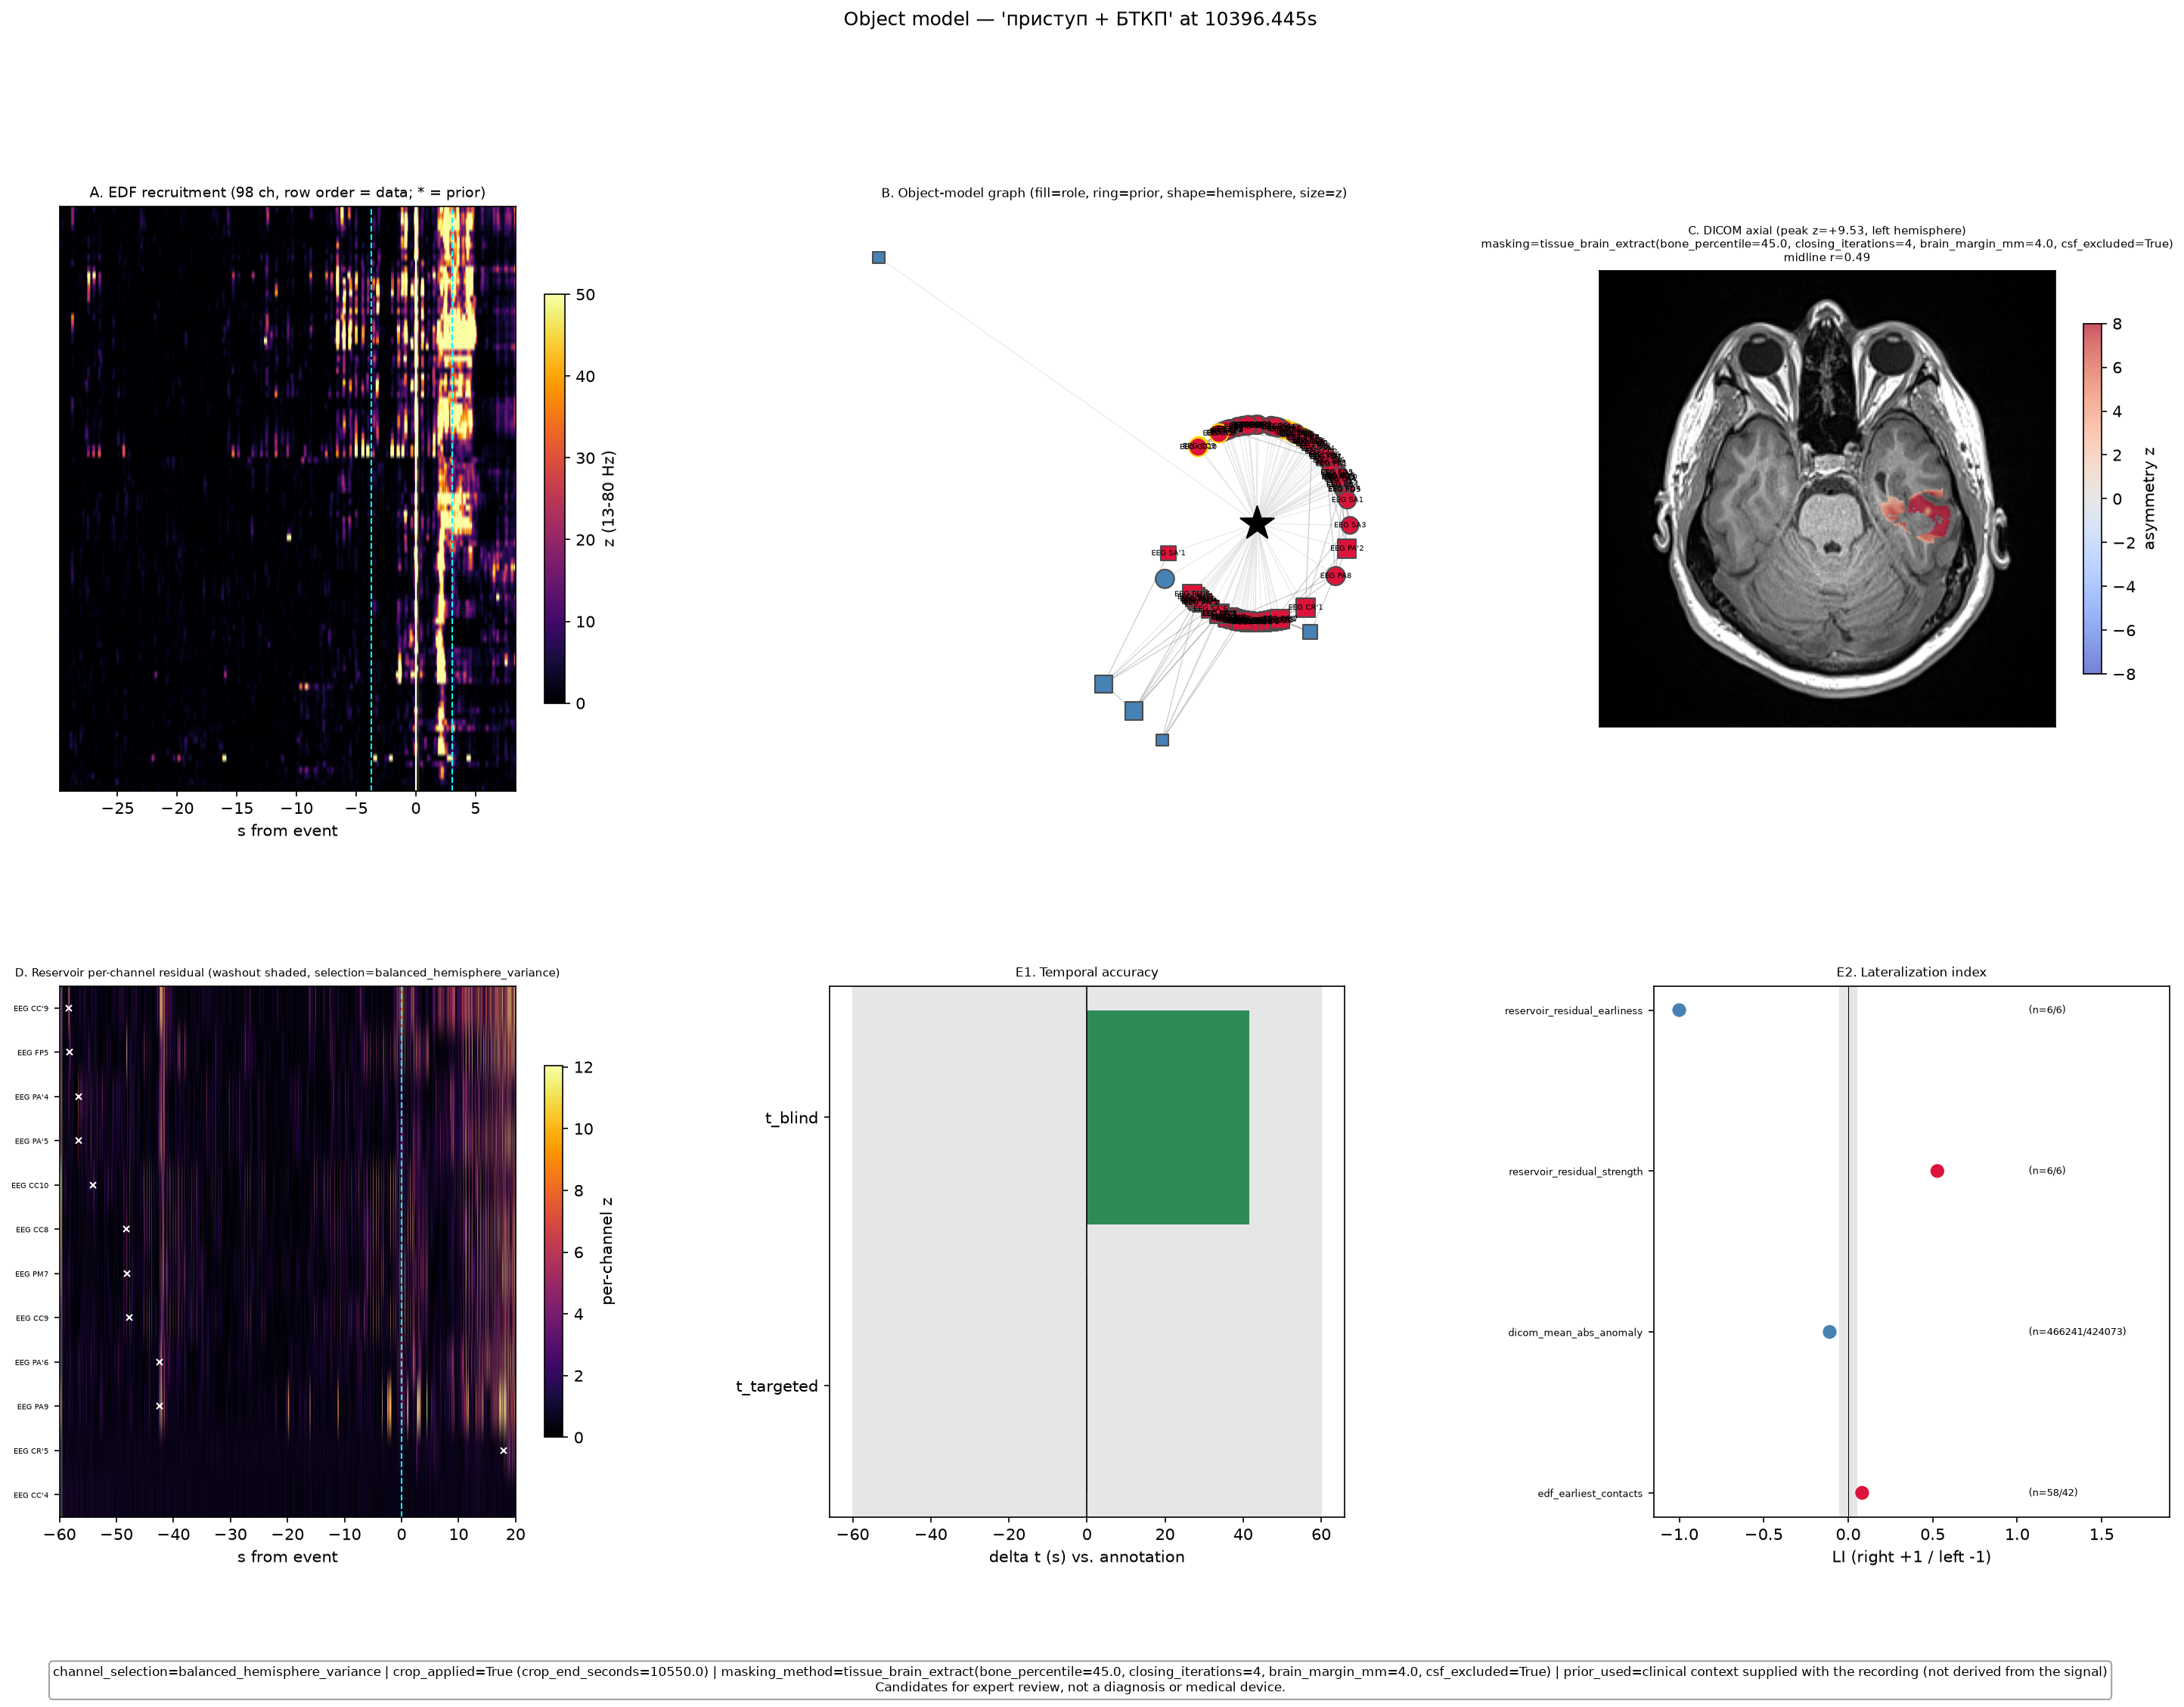

In [11]:
from IPython.display import Image, display
display(Image(filename=str(figure_path)))

## 8. Summary: what this run resolved, and what it honestly did not

Read in this order (see the top-level README, "What to look at in the result", for the full discussion):

1. **`hemisphere_of_earliest`** -- printed in Block A -- is the prior-free answer to "which side fired first". `right` would confirm the clinical prior with independent data; `left` would flip the picture toward the structural finding instead; `mixed` (the usual result on this recording) means the temporal channel does not resolve laterality by itself at all.
2. **Whether the four `report.lateralization` entries agree** (`report.lateralization_agreement`, printed in Block C) -- disagreement between EDF, DICOM, and the reservoir is a valid, reportable outcome here, not a failure of the pipeline.
3. **`check_implant_hypothesis`'s `implant_proximity_correlation`** (Block B) -- whether the structural asymmetry channel is substantially just tracking the implant rather than anatomy.
4. **Nothing above is a diagnosis.** Every output in this notebook is a candidate for expert review of the raw EDF, DICOM, montage, and clinical record -- consistent with the rest of this repository.